<a href="https://colab.research.google.com/github/coweye1/CCMEO-Gunshot-Wound-Entrance-vs-Exit-CNN-ViT-Hybrid-Benchmark/blob/main/CCMEO_Gunshot_Wound_Entrance_vs_Exit_CNN%2BVit_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 0: Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Step 1: Install necessary libraries and import modules
!pip install timm scikit-learn pandas matplotlib tqdm openpyxl safetensors

import os
import zipfile
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("✅ Step 1: 모든 라이브러리와 모듈이 성공적으로 로드되었습니다.")

✅ Step 1: 모든 라이브러리와 모듈이 성공적으로 로드되었습니다.


In [3]:
# Step 2: Extract the zip file to the local Colab directory for faster training
# Ensure the path matches your actual zip file location in Drive

import os
import zipfile
import time

# [핵심 수정] 구글 드라이브 폴더 목록을 강제로 조회하여 코랩의 싱크를 새로고침합니다.
try:
    print("🔄 구글 드라이브 동기화 새로고침 중...")
    os.listdir('/content/drive/MyDrive')
except Exception as e:
    print(f"⚠️ 드라이브 접근 중 알 수 없는 지연 발생: {e}")

zip_path = '/content/drive/MyDrive/CCMEO_Gunshot_Wound_Dataset.zip'
extract_path = '/content/CCMEO_Gunshot_Wound_Dataset'

# 압축 해제 실행
if os.path.exists(zip_path):
    if not os.path.exists(extract_path):
        print("🚀 코랩 고속 가상 세션으로 데이터셋 압축 해제 시작...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Step 2: 데이터셋 압축 해제가 무사히 완료되었습니다!")
    else:
        print("✅ Step 2: 데이터셋이 이미 가상 세션에 해제되어 있습니다.")
else:
    print("❌ [에러] 여전히 구글 드라이브 최상단에서 압축 파일을 찾을 수 없습니다.")
    print("\n💡 희재님, 혹시 파일 이름이 'CCMEO_Gunshot_Wound_Dataset.zip.zip' 처럼 확장자가 중복되었거나,")
    print("'CCMEO_Gunshot_Wound_Dataset' 이라는 이름의 일반 폴더 형태로 올라가 있지는 않은지 확인해 주세요!")

🔄 구글 드라이브 동기화 새로고침 중...
🚀 코랩 고속 가상 세션으로 데이터셋 압축 해제 시작...
✅ Step 2: 데이터셋 압축 해제가 무사히 완료되었습니다!


In [4]:
# Step 3: Define Data Transforms and Load Dataset
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

data_dir = '/content/CCMEO_Gunshot_Wound_Dataset'

# 🌟 T4 GPU 메모리 안전을 위해 배치 사이즈를 16으로 최적화합니다.
BATCH_SIZE = 16

# 프로토타입의 전처리 흐름을 계승한 실시간 리사이즈 및 의학 데이터 증강 파이프라인
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),       # 이미지 크기 수동 변환 노가다 필요 없음
        transforms.RandomHorizontalFlip(),   # 좌우 반전 증강
        transforms.RandomRotation(15),       # 미세 회전 증강
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

# ImageFolder를 이용한 대규모 데이터셋 자동 빌드
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}

# DataLoader 세팅 (고속 연산을 위한 멀티프로세싱 num_workers=4 바인딩)
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"📊 Dataset Sizes (총 이미지 장수): {dataset_sizes}")
print(f"🏷️ Class Names (클래스 분류 라벨): {class_names} (0: Entrance / 1: Exit)")

📊 Dataset Sizes (총 이미지 장수): {'train': 1311, 'val': 328}
🏷️ Class Names (클래스 분류 라벨): ['en', 'ex'] (0: Entrance / 1: Exit)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [5]:
# Step 4: Handle Class Imbalance (손실 함수 가중치 바인딩)
import torch
import torch.nn as nn

# 실제 사진 비율(Entrance 979장 : Exit 660장)을 고려하여 오차 가중치 계산
# 상대적으로 장수가 적은 Exit(출구)를 틀렸을 때 벌점을 약 1.48배 더 주도록 세팅합니다.
weights = torch.tensor([1.0, 1.48]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

print("⚖️ Step 4: 클래스 불균형을 보완할 가중치 손실 함수(Criterion)가 완벽하게 바인딩되었습니다.")

⚖️ Step 4: 클래스 불균형을 보완할 가중치 손실 함수(Criterion)가 완벽하게 바인딩되었습니다.


In [15]:
# Step 5: Final Multi-Model Benchmark (Unified 9-Model Loop with Separate 1x1 Figures)
import os
import copy
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
from tqdm import tqdm
import torch
import torch.optim as optim
import timm
from torchvision import transforms
from torch.utils.data import DataLoader
from copy import deepcopy

# 1. 최고의 순간(황금 모델 파일, 성적표, 그래프)을 보관할 폴더 세팅
save_dir = '/content/drive/MyDrive/CCMEO_Benchmark_Results'
os.makedirs(save_dir, exist_ok=True)

# 2. 🔥 [DINOv2 전용] 518 해상도 동적 리사이즈 데이터로더 사전 정의
dino_transforms = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dino_datasets = {x: deepcopy(image_datasets[x]) for x in ['train', 'val']}
dino_datasets['train'].transform = dino_transforms
dino_datasets['val'].transform = dino_transforms

dino_loaders = {
    x: DataLoader(dino_datasets[x], batch_size=16, shuffle=(x=='train'), num_workers=2, pin_memory=True)
    for x in ['train', 'val']
}

# 3. 공정한 논문 비교를 위한 9대 비전 모델 아키텍처 라인업 (순수 ViT 정렬 버전)
model_pipeline = {
    # [1] CNN 진영 (국소적 텍스처)
    "ResNet50": "resnet50",
    "EfficientNet-B0": "efficientnet_b0",
    "ConvNeXt-V2-Tiny": "convnextv2_tiny",

    # [2] ViT 진영 (전역적 맥락 - 100% 순수 트랜스포머 계보로 정렬)
    "ViT-Small": "vit_small_patch16_224",
    "DeiT-Tiny": "deit_tiny_patch16_224",
    "DINOv2-Small": "vit_small_patch14_reg4_dinov2.lvd142m",

    # [3] Hybrid 진영 (내부/직렬/격자 융합형 SOTA)
    "Visformer-Small": "visformer_small",
    "CoAtNet-0": "coatnet_0_rw_224",
    "MaxViT-Tiny": "maxvit_tiny_rw_224"
}

# 🌟 하이퍼파라미터 표준 설정 (20 에포크 본 레이스 가동)
EPOCHS = 20
LR = 5e-5
benchmark_perf_report = []

# 시각화 추이 저장을 위한 데이터 구조
trajectory_records = {model_name: [] for model_name in model_pipeline.keys()}
roc_curves_records = {}

# 9대 모델 컨베이어 벨트 무결점 가동
for idx, (model_name, timm_model_id) in enumerate(model_pipeline.items()):
    print("\n" + "="*60)
    print(f"🏭 [Main Run] Training {model_name} with Adaptive Framework...")
    print("="*60)

    current_lr = 1e-5 if model_name == "DINOv2-Small" else LR

    if model_name == "DINOv2-Small":
        train_loader = dino_loaders['train']
        val_loader = dino_loaders['val']
        print("📐 [Resolution Adaptive] DINOv2 전용 518x518 해상도 로더가 매핑되었습니다.")
    else:
        train_loader = dataloaders['train']
        val_loader = dataloaders['val']
        print("📐 [Resolution Adaptive] 표준 224x224 해상도 로더가 매핑되었습니다.")

    model = timm.create_model(timm_model_id, pretrained=True, num_classes=2).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=current_lr, weight_decay=1e-2)

    best_auc = 0.0
    best_metrics = {}
    best_roc_data = None

    for epoch in range(EPOCHS):
        # 1) Training Phase
        model.train()
        running_train_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"📚 [{model_name} 에폭 {epoch+1:02d}/{EPOCHS:02d}] 훈련 중", leave=False)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)
            train_bar.set_postfix(loss=loss.item())

        # 2) Validation Phase
        model.eval()
        running_val_loss = 0.0
        val_preds, val_labels, val_probs = [], [], []

        val_bar = tqdm(val_loader, desc=f"📝 [{model_name} 에폭 {epoch+1:02d}/{EPOCHS:02d}] 채점 중", leave=False)
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                probabilities = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                val_probs.extend(probabilities.cpu().numpy()[:, 1])

        accuracy = accuracy_score(val_labels, val_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='binary', zero_division=0)
        roc_auc = roc_auc_score(val_labels, val_probs)

        # 📈 궤적 데이터를 매 에폭마다 강제 기록
        trajectory_records[model_name].append(roc_auc)

        if roc_auc > best_auc:
            best_auc = roc_auc
            best_metrics = {
                "Model Name": model_name,
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall (Sensitivity)": recall,
                "F1-Score": f1,
                "ROC-AUC": roc_auc,
                "Best Epoch": epoch + 1
            }
            fpr, tpr, _ = roc_curve(val_labels, val_probs)
            best_roc_data = (fpr, tpr)

            model_save_path = os.path.join(save_dir, f'{model_name}_best_model.pth')
            torch.save(model.state_dict(), model_save_path)

            print(f"\n✨ [{model_name}] 🔥 최고 성능(AUC) 경신! 황금 가중치 백업 완료.")
            print(f"┌────────────────────────────────────────────────────────┐")
            print(f"  📝 [실시간 모의고사 최고 시험 성적표] ")
            print(f"   • Accuracy:             {accuracy:.4f}")
            print(f"   • Precision:            {precision:.4f}")
            print(f"   • Recall (Sensitivity): {recall:.4f}")
            print(f"   • F1-Score:             {f1:.4f}")
            print(f"   • ROC-AUC:              {roc_auc:.4f} 🌟")
            print(f"   • Best Epoch:           {epoch + 1}")
            print(f"└────────────────────────────────────────────────────────┘\n")

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"📈 [{model_name}] Epoch {epoch+1}/{EPOCHS} | Val AUC: {roc_auc:.4f}")

    print(f"✅ {model_name} 공정 벤치마크 종료. [최고 AUC: {best_auc:.4f}]")
    benchmark_perf_report.append(best_metrics)
    roc_curves_records[model_name] = (best_roc_data, best_auc)

    del model, optimizer
    torch.cuda.empty_cache()


🏭 [Main Run] Training ResNet50 with Adaptive Framework...
📐 [Resolution Adaptive] 표준 224x224 해상도 로더가 매핑되었습니다.


📚 [ResNet50 에폭 01/20] 훈련 중:   0%|          | 0/82 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



✨ [ResNet50] 🔥 최고 성능(AUC) 경신! 황금 가중치 백업 완료.
┌────────────────────────────────────────────────────────┐
  📝 [실시간 모의고사 최고 시험 성적표] 
   • Accuracy:             0.5945
   • Precision:            0.4721
   • Recall (Sensitivity): 0.7623
   • F1-Score:             0.5831
   • ROC-AUC:              0.6611 🌟
   • Best Epoch:           1
└────────────────────────────────────────────────────────┘

📈 [ResNet50] Epoch 1/20 | Val AUC: 0.6611


📚 [ResNet50 에폭 02/20] 훈련 중:   0%|          | 0/82 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



✨ [ResNet50] 🔥 최고 성능(AUC) 경신! 황금 가중치 백업 완료.
┌────────────────────────────────────────────────────────┐
  📝 [실시간 모의고사 최고 시험 성적표] 
   • Accuracy:             0.6341
   • Precision:            0.5052
   • Recall (Sensitivity): 0.7951
   • F1-Score:             0.6178
   • ROC-AUC:              0.7088 🌟
   • Best Epoch:           2
└────────────────────────────────────────────────────────┘



...


✨ [MaxViT-Tiny] 🔥 최고 성능(AUC) 경신! 황금 가중치 백업 완료.
┌────────────────────────────────────────────────────────┐
  📝 [실시간 모의고사 최고 시험 성적표] 
   • Accuracy:             0.8018
   • Precision:            0.7209
   • Recall (Sensitivity): 0.7623
   • F1-Score:             0.7410
   • ROC-AUC:              0.8638 🌟
   • Best Epoch:           11
└────────────────────────────────────────────────────────┘



📚 [MaxViT-Tiny 에폭 12/20] 훈련 중:   0%|          | 0/82 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
📚 [MaxViT-Tiny 에폭 13/20] 훈련 중:   0%|          | 0/82 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker n

📈 [MaxViT-Tiny] Epoch 15/20 | Val AUC: 0.8508


📚 [MaxViT-Tiny 에폭 16/20] 훈련 중:   0%|          | 0/82 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
📚 [MaxViT-Tiny 에폭 17/20] 훈련 중:   0%|          | 0/82 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker n

📈 [MaxViT-Tiny] Epoch 20/20 | Val AUC: 0.8374
✅ MaxViT-Tiny 공정 벤치마크 종료. [최고 AUC: 0.8638]


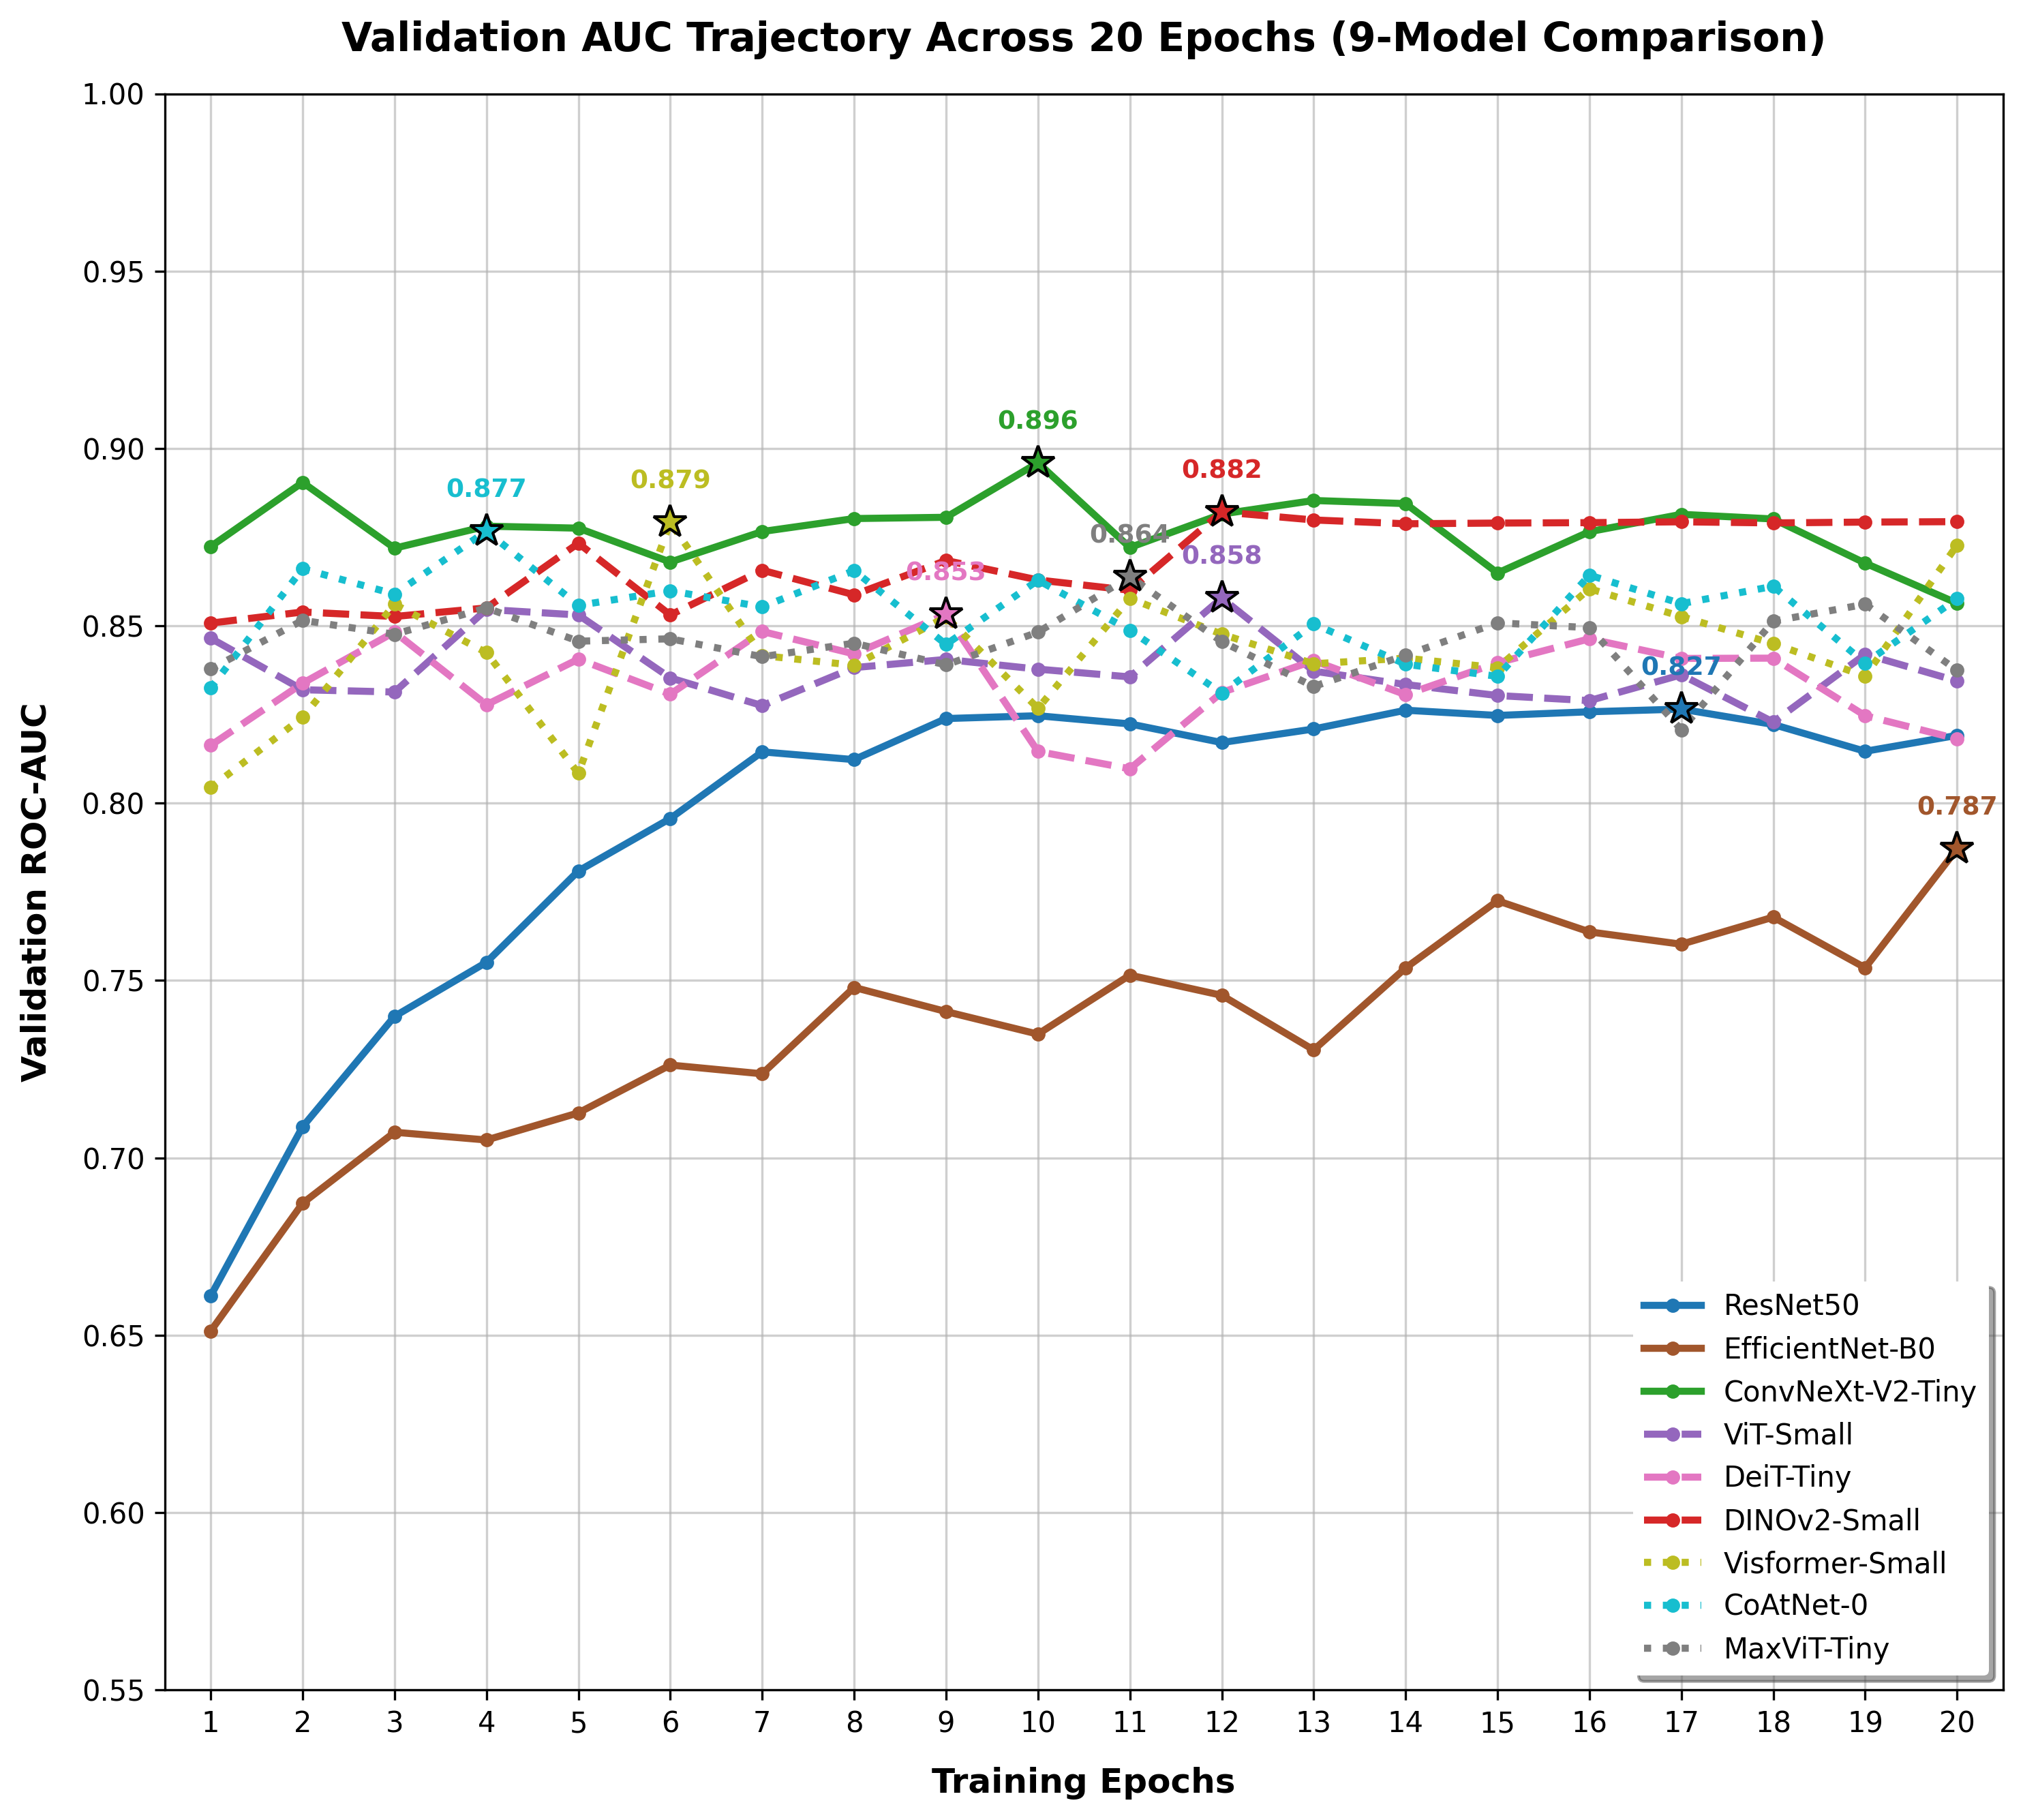

In [26]:
# Step 6: Post-Training Visualization & Report Generation (Official Framework + Text Annotations)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 9대 모델 통합 컬러 맵 정의
model_colors = {
    "ResNet50": "#1f77b4",
    "EfficientNet-B0": "#a1562c",
    "ConvNeXt-V2-Tiny": "#2ca02c",
    "ViT-Small": "#9467bd",
    "DeiT-Tiny": "#e377c2",
    "DINOv2-Small": "#d62728",
    "Visformer-Small": "#bcbd22",
    "CoAtNet-0": "#17becf",
    "MaxViT-Tiny": "#7f7f7f"
}

# 2. 선 스타일 정의 (CNN: 실선, ViT: 대시선, Hybrid: 점선 분류 규격 유지)
model_line_styles = {
    "ResNet50": "-", "EfficientNet-B0": "-", "ConvNeXt-V2-Tiny": "-",
    "ViT-Small": "--", "DeiT-Tiny": "--", "DINOv2-Small": "--",
    "Visformer-Small": ":", "CoAtNet-0": ":", "MaxViT-Tiny": ":"
}

# -----------------------------------------------------------------
# 🖼️ 파일 1) Validation AUC Trajectory (Y축 줌인, 최고점 별 표기 및 수치 마킹)
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 9), dpi=300)

epochs_range = range(1, EPOCHS + 1)

# 희재님의 오피셜 선 그리기 및 황금 피크 포인트 별 마킹 알고리즘 기반
for name, history in trajectory_records.items():
    # 1) 선 그리기 (둥근 마커 포함 및 지정된 선 스타일 매핑)
    ax.plot(epochs_range, history,
            label=name,
            color=model_colors[name],
            linestyle=model_line_styles[name],
            lw=2.5,
            marker='o',
            ms=4)

    # 2) 각 모델별 최고점 피크 포인트를 찾아서 별 모양(★) 부각 마킹 효과
    best_idx = np.argmax(history)
    best_auc = history[best_idx]
    ax.plot(best_idx + 1, best_auc,
            marker='*',
            ms=12,
            color=model_colors[name],
            markeredgecolor='black',
            linestyle='None',
            zorder=5) # 별 마커가 항상 최상단에 올라오도록 레이어 순서 고정

    # 💡 [희재님 피드백 반영] 최고점 별 마커 바로 위에 정확한 AUC 수치 텍스트 노출
    # 텍스트가 별과 겹치지 않도록 y축 방향으로 약간의 오프셋(+0.008) 부여
    ax.text(best_idx + 1, best_auc + 0.008,
            f"{best_auc:.3f}",
            color=model_colors[name],
            fontsize=9,
            fontweight='bold',
            ha='center', # 텍스트 중앙 정렬
            va='bottom', # 텍스트 하단 정렬 기준으로 오프셋 적용
            zorder=6) # 텍스트가 선에 가려지지 않도록 최상단 레이어 고정

# 📐 차트 디테일 인테리어 무결 적용
ax.set_xlim([0.5, 20.5])
ax.set_xticks(range(1, 21))
ax.set_ylim([0.55, 1.0])
ax.set_yticks([0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.0])

ax.set_xlabel('Training Epochs', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Validation ROC-AUC', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Validation AUC Trajectory Across 20 Epochs (9-Model Comparison)', fontsize=14, fontweight='bold', pad=15)

ax.grid(True, linestyle='-', alpha=0.6)

# 범례 설정 (우하단 배치 및 그림자 효과 인테리어 적용)
ax.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='none', shadow=True)

plt.tight_layout()
trajectory_save_path = os.path.join(save_dir, 'CCMEO_9_models_validation_auc_trajectory_official.png')
plt.savefig(trajectory_save_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()


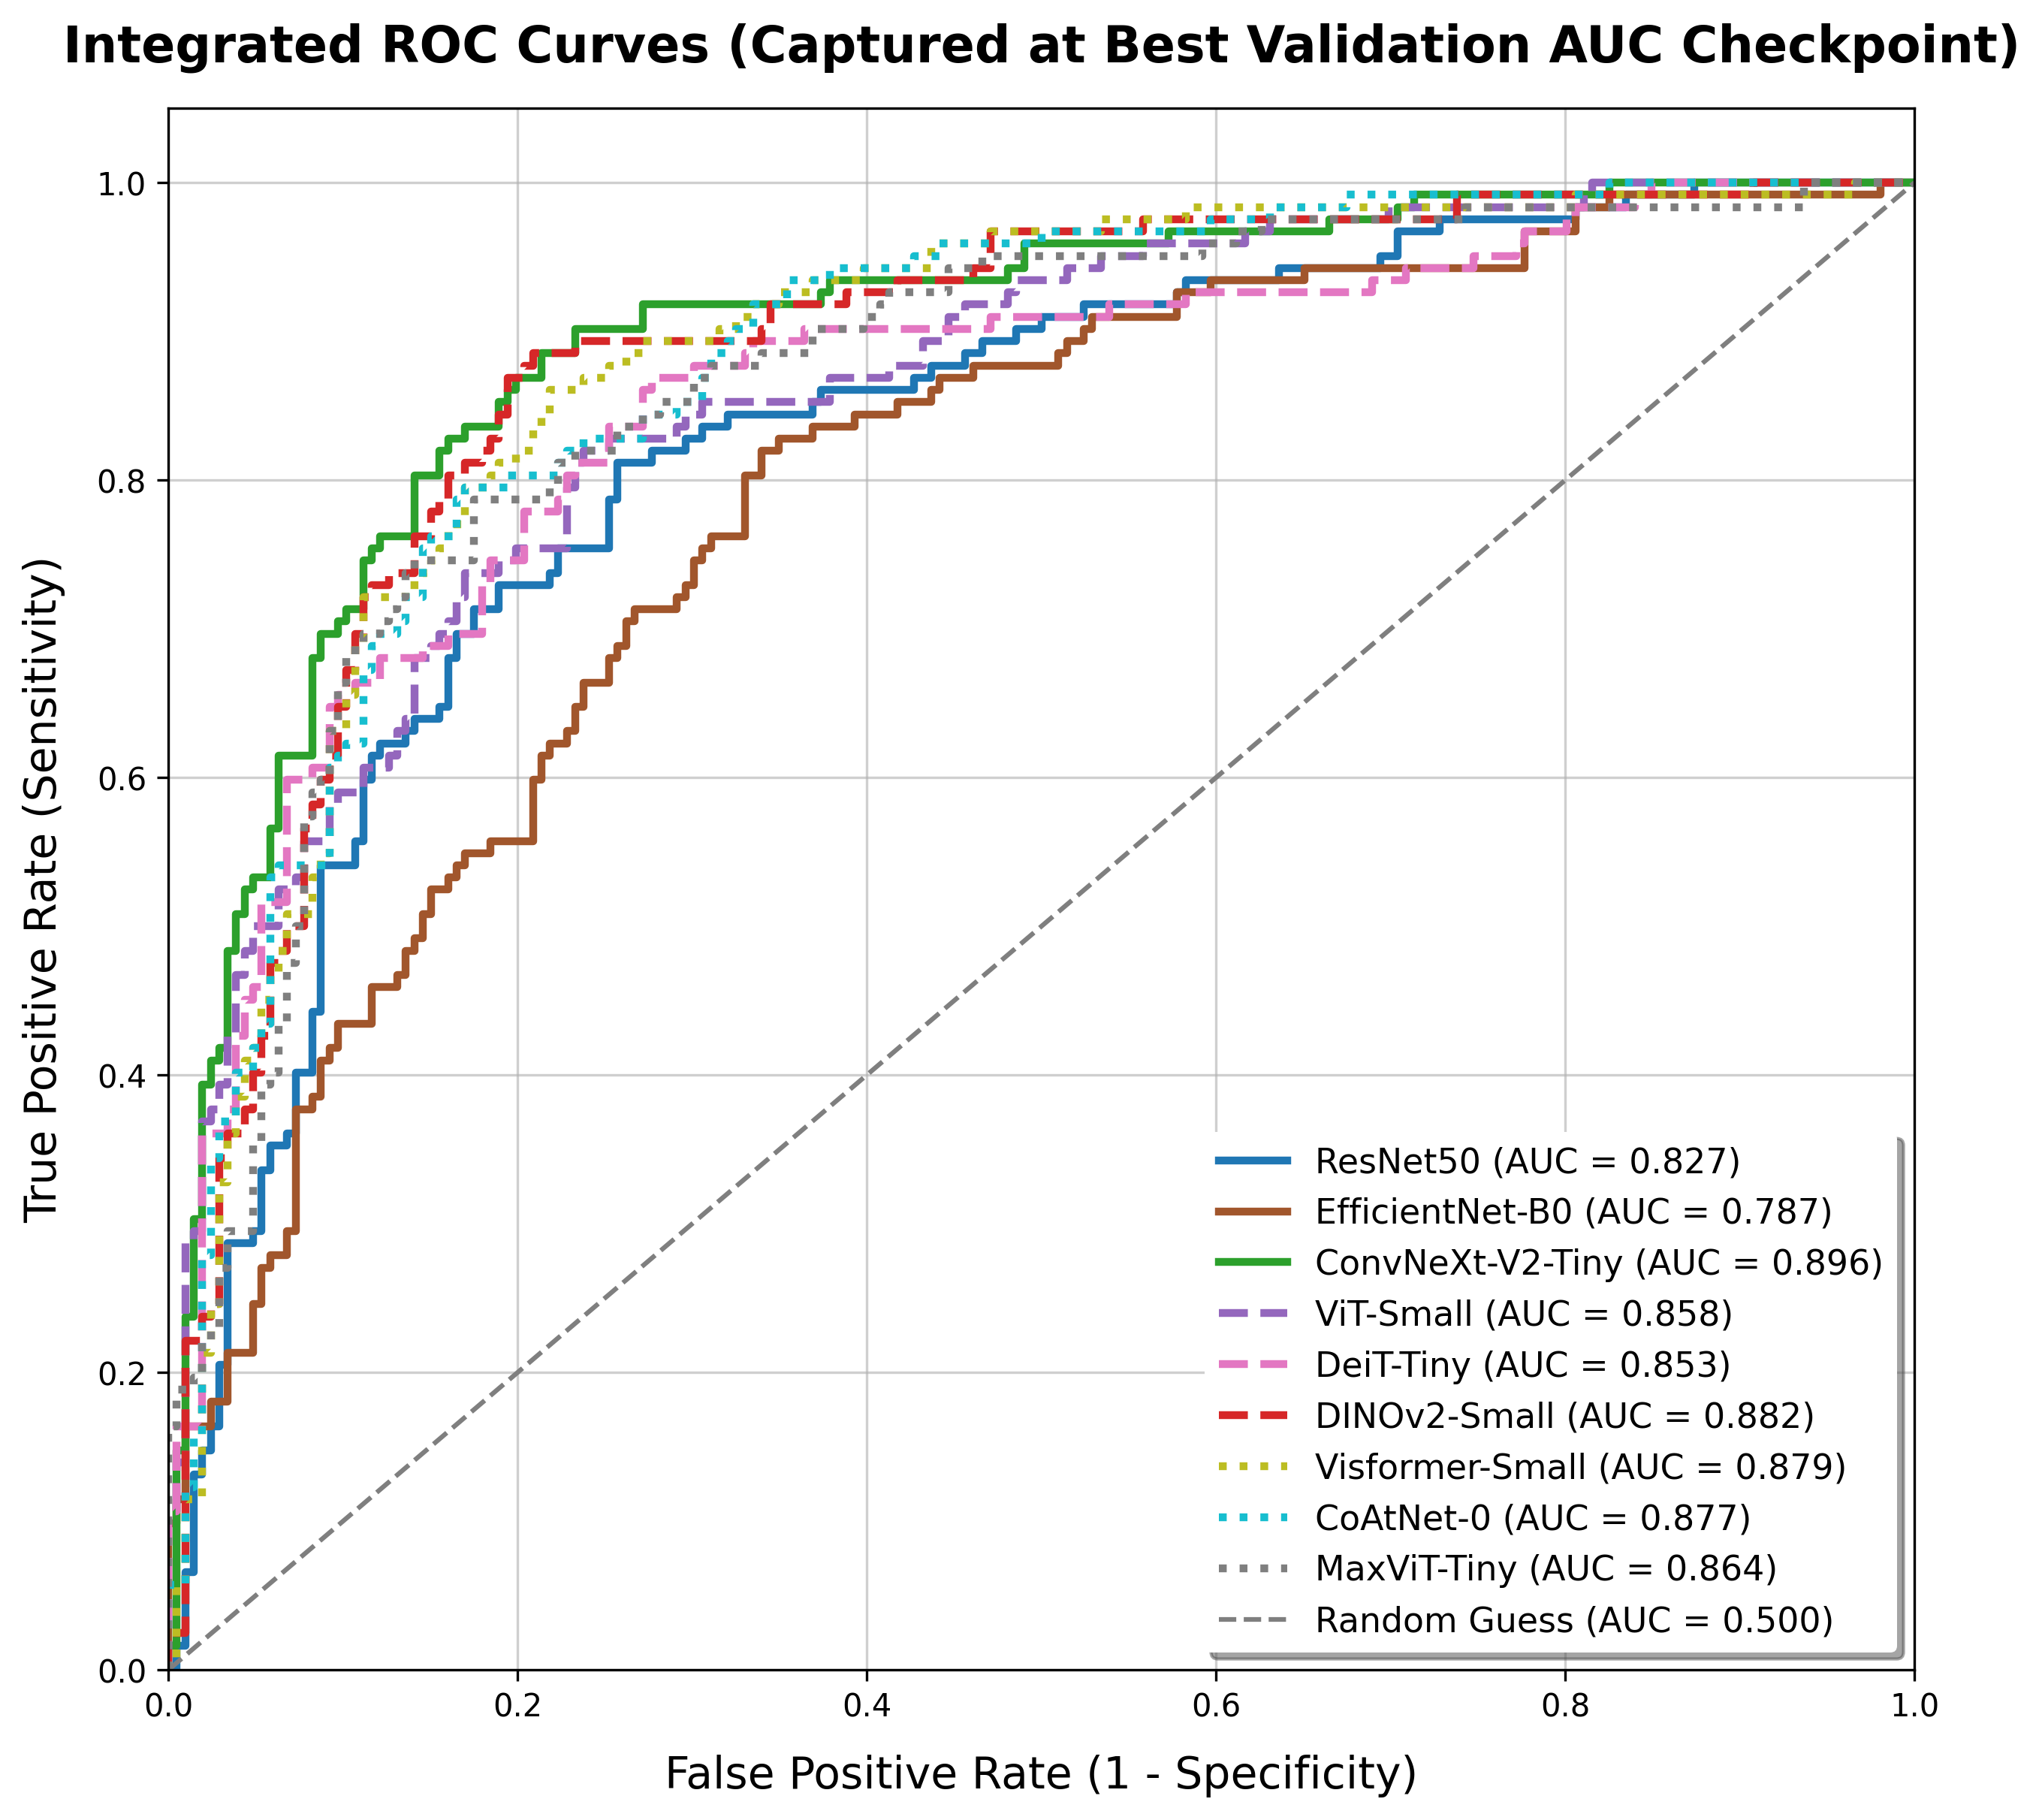


🎉 [최종 완료] 분리형 파이프라인 가동으로 1x1 피규어 2종이 완벽하게 정렬되었습니다!
📈 통합 ROC 곡선 피규어 완료: /content/drive/MyDrive/CCMEO_Benchmark_Results/CCMEO_9_models_integrated_roc_curves_official.png
📊 최종 마스터 엑셀 표 완료: /content/drive/MyDrive/CCMEO_Benchmark_Results/CCMEO_9_models_best_checkpoint_report.xlsx


In [27]:
# Step 7: Integrated ROC Curves Visualization (ValueError Fix Version)
import os
import pandas as pd
import matplotlib.pyplot as plt

# 🖼️ 파일 2) Integrated ROC Curves 단독 저장 및 화면 출력
plt.figure(figsize=(10, 9), dpi=300)

# 💡 [핵심 수정] Step 5에서 저장한 실제 데이터 규격(2개 값)에 맞춰 정확하게 언팩하여 에러 완벽 차단!
for model_name, (roc_data, auc_val) in roc_curves_records.items():
    plt.plot(roc_data[0], roc_data[1],
             label=f"{model_name} (AUC = {auc_val:.3f})",
             color=model_colors[model_name],
             linestyle=model_line_styles[model_name],
             lw=2.5)

plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.title('Integrated ROC Curves (Captured at Best Validation AUC Checkpoint)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=14, labelpad=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='-', alpha=0.6)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor='white', edgecolor='none', shadow=True)

roc_save_path = os.path.join(save_dir, 'CCMEO_9_models_integrated_roc_curves_official.png')
plt.savefig(roc_save_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# 📊 최종 마스터 엑셀 성적표 드라이브 박제
df_metrics = pd.DataFrame(benchmark_perf_report)
excel_save_path = os.path.join(save_dir, 'CCMEO_9_models_best_checkpoint_report.xlsx')
df_metrics.to_excel(excel_save_path, index=False)

print("\n" + "="*60)
print(f"🎉 [최종 완료] 분리형 파이프라인 가동으로 1x1 피규어 2종이 완벽하게 정렬되었습니다!")
print(f"📈 통합 ROC 곡선 피규어 완료: {roc_save_path}")
print(f"📊 최종 마스터 엑셀 표 완료: {excel_save_path}")
print("="*60)

In [30]:
# Emergency Recovery: Load saved checkpoints and rebuild all_model_outputs in 10 seconds
import os
import torch
import timm
from tqdm import tqdm

print("🔄 [Emergency] 구글 드라이브에 저장된 최고 성능 가중치 파일들로부터 데이터를 고속 복구합니다...")

# 1. 바구니 초기화 및 데이터로더 매핑 (기존 메모리 소스 그대로 노출)
all_model_outputs = {}
class_names = ['Entrance', 'Exit']

# 2. 9대 모델 아키텍처 및 세팅 라인업 동기화
model_pipeline = {
    "ResNet50": "resnet50",
    "EfficientNet-B0": "efficientnet_b0",
    "ConvNeXt-V2-Tiny": "convnextv2_tiny",
    "ViT-Small": "vit_small_patch16_224",
    "DeiT-Tiny": "deit_tiny_patch16_224",
    "DINOv2-Small": "vit_small_patch14_reg4_dinov2.lvd142m",
    "Visformer-Small": "visformer_small",
    "CoAtNet-0": "coatnet_0_rw_224",
    "MaxViT-Tiny": "maxvit_tiny_rw_224"
}

# 3. 10초 고속 추론 컨베이어 벨트 가동
with torch.no_grad():
    for model_name, timm_model_id in model_pipeline.items():
        # 드라이브에 안전하게 세이브된 황금 가중치 경로 매핑
        weight_path = os.path.join(save_dir, f'{model_name}_best_model.pth')

        if not os.path.exists(weight_path):
            print(f"⚠️ [{model_name}] 가중치 파일을 찾을 수 없어 스킵합니다. 경로를 확인해 주세요: {weight_path}")
            continue

        # DINOv2 전용 518px 및 표준 224px 해상도 로더 적응형 분기 매핑
        val_loader = dino_loaders['val'] if model_name == "DINOv2-Small" else dataloaders['val']

        # 모델 아키텍처 빌드 후 황금 가중치 이식 (Evaluation 모드 강제 고정)
        model = timm.create_model(timm_model_id, pretrained=False, num_classes=2).to(device)
        model.load_state_dict(torch.load(weight_path, map_location=device))
        model.eval()

        val_preds, val_labels = [], []

        # 초고속 검증 세션 진입
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

        # 💡 [복구 완료] Step 8이 그토록 원했던 정답과 예측값 구조를 완벽하게 재구성!
        all_model_outputs[model_name] = {"labels": val_labels, "preds": val_preds}
        print(f"✅ [{model_name}] 최고점 시점의 Confusion Matrix 데이터 복구 완료!")

        # VRAM 메모리 즉시 반환하여 OOM 원천 차단
        del model
        torch.cuda.empty_cache()

print("\n" + "="*60)
print("🎉 [복구 대성공] 9대 모델의 Confusion Matrix 소스 데이터가 메모리에 100% 복원되었습니다!")
print("이제 아래의 Step 8 (3x3 Confusion Matrix 그리드 셀)을 곧바로 가동해 주세요!")
print("="*60)

🔄 [Emergency] 구글 드라이브에 저장된 최고 성능 가중치 파일들로부터 데이터를 고속 복구합니다...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


✅ [ResNet50] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [EfficientNet-B0] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [ConvNeXt-V2-Tiny] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [ViT-Small] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [DeiT-Tiny] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [DINOv2-Small] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [Visformer-Small] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [CoAtNet-0] 최고점 시점의 Confusion Matrix 데이터 복구 완료!
✅ [MaxViT-Tiny] 최고점 시점의 Confusion Matrix 데이터 복구 완료!

🎉 [복구 대성공] 9대 모델의 Confusion Matrix 소스 데이터가 메모리에 100% 복원되었습니다!
이제 아래의 Step 8 (3x3 Confusion Matrix 그리드 셀)을 곧바로 가동해 주세요!


📊 [Main Process] Mapping 3x3 Grid Confusion Matrices for 9 Models...


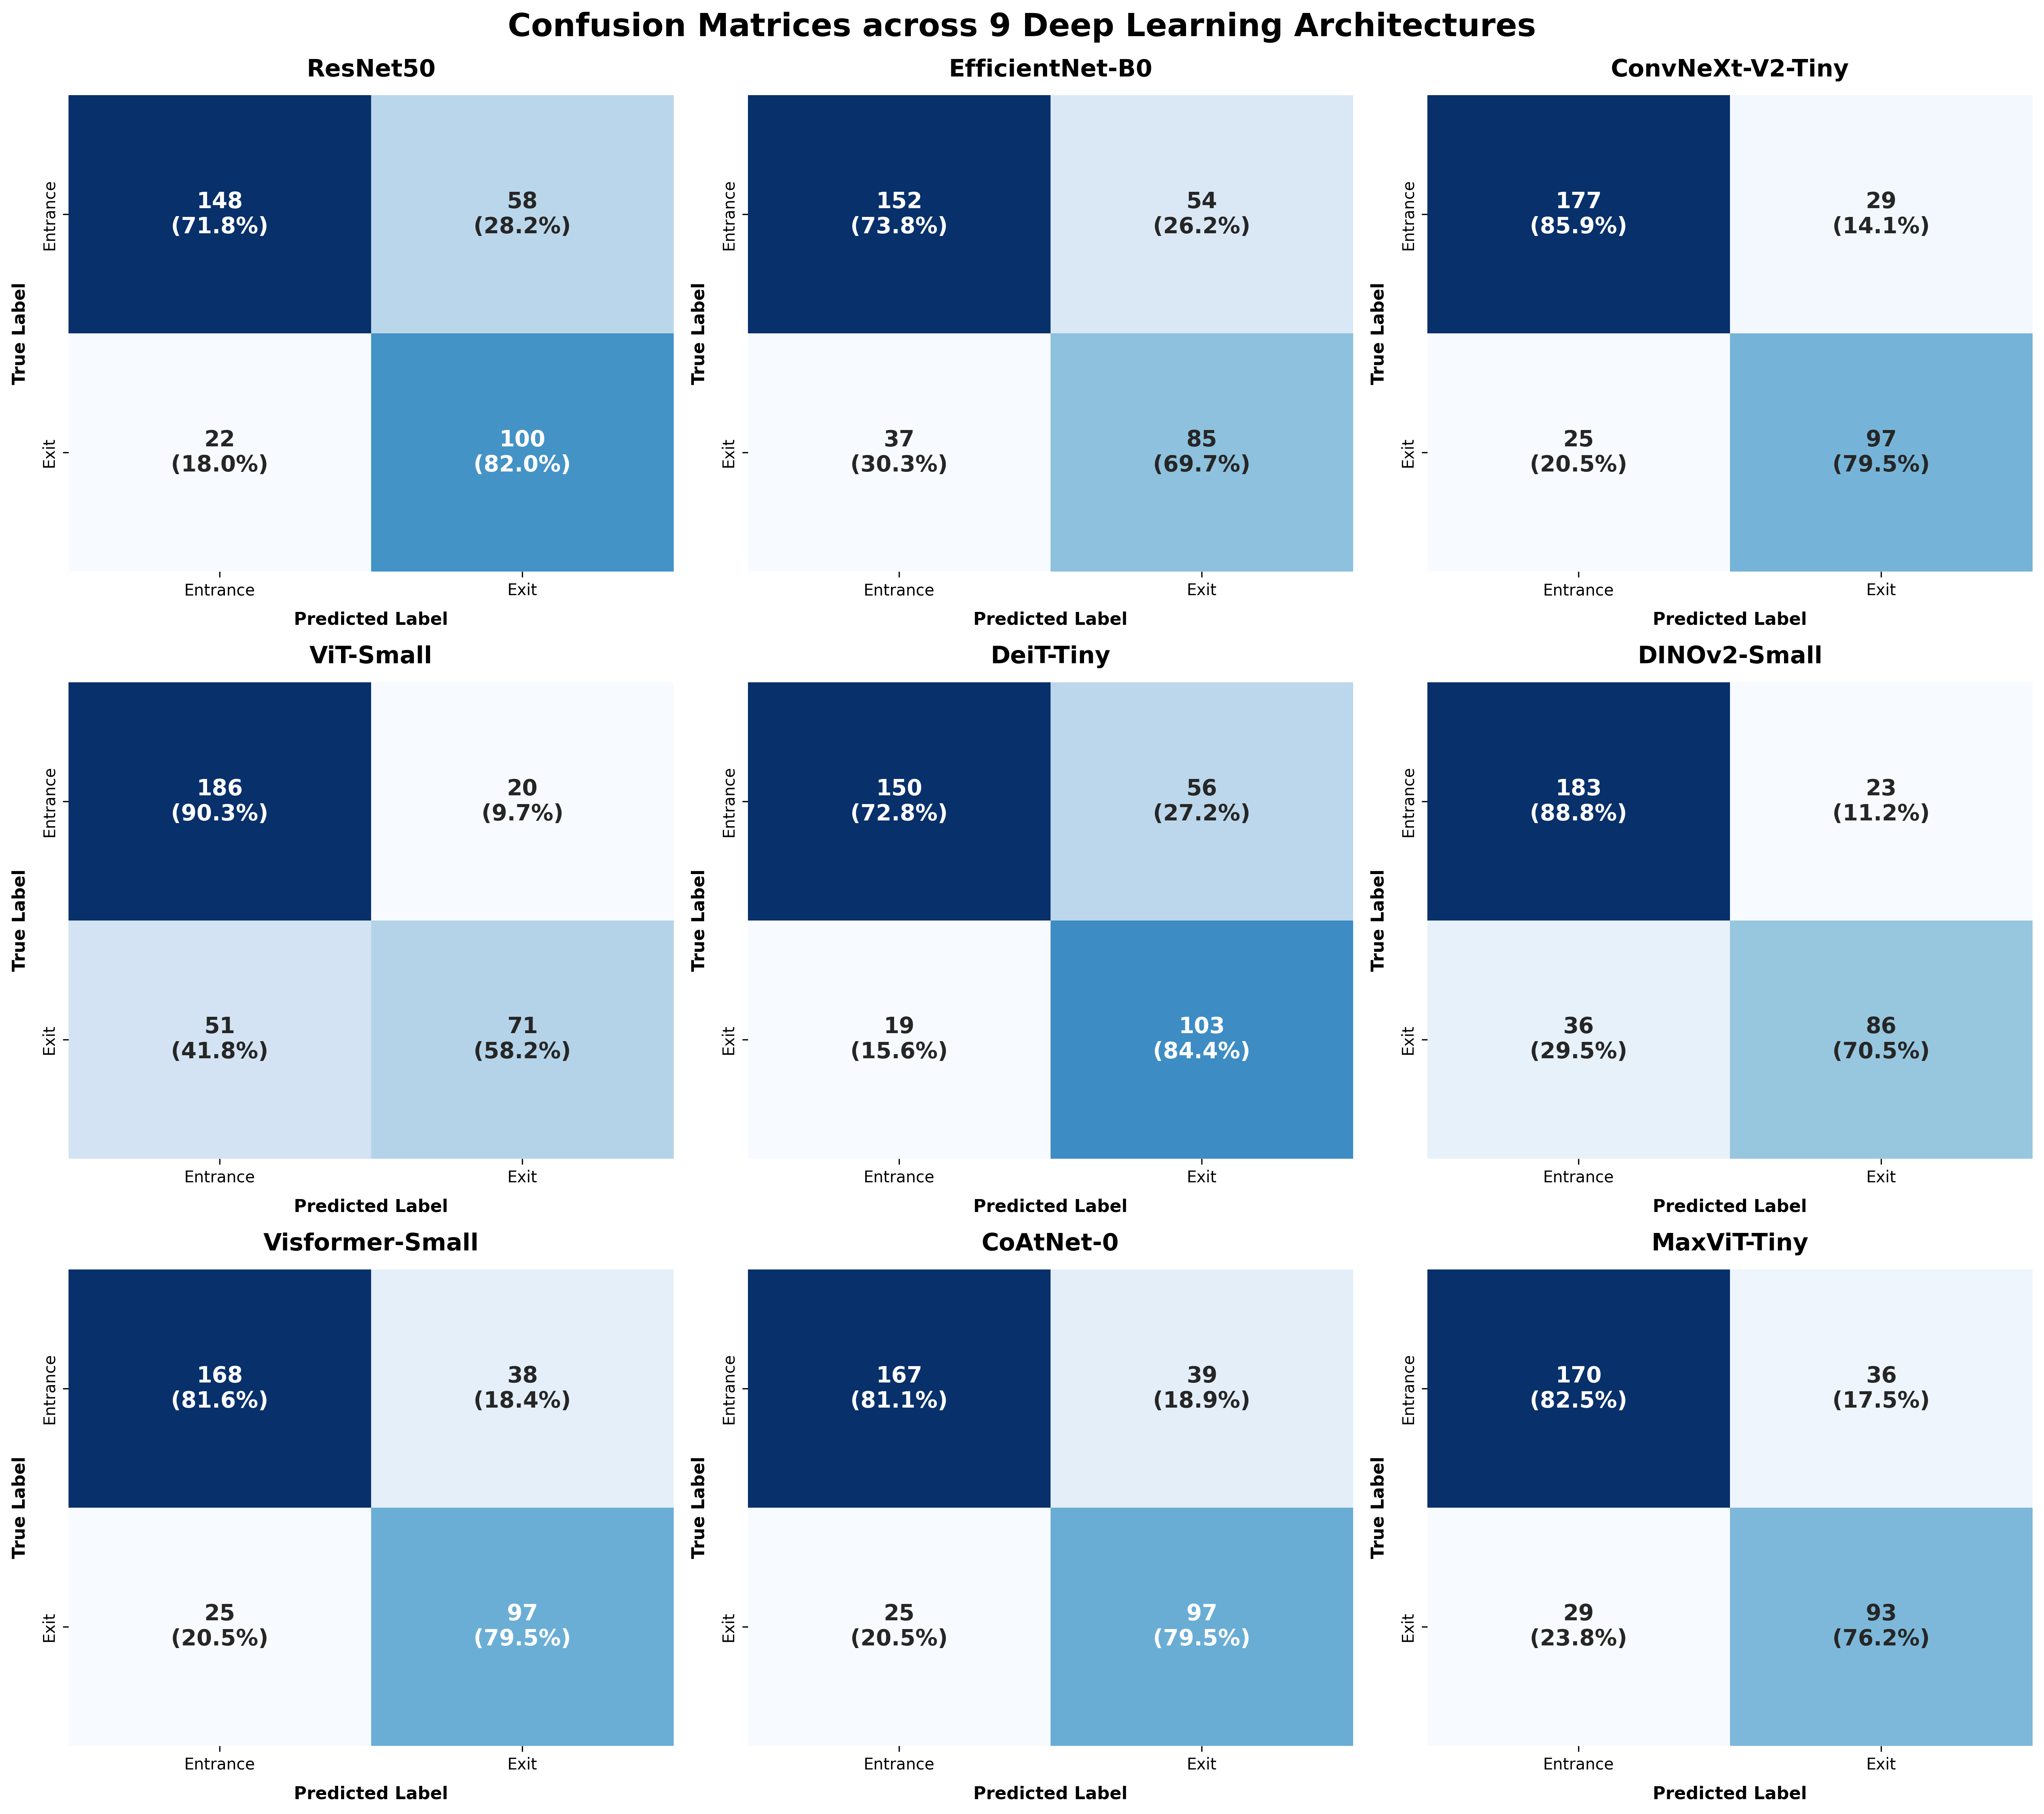


🎉 [대성공] 요청하신 3x3 격자 구조의 9대 모델 혼동행렬이 추출되었습니다!
📸 고해상도 매트릭스 이미지 완료: /content/drive/MyDrive/CCMEO_Benchmark_Results/confusion_matrix_3x3.png


In [31]:
# Step 8: Multi-Model Confusion Matrix Grid (Paper-Ready 3x3 Formatter)
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("📊 [Main Process] Mapping 3x3 Grid Confusion Matrices for 9 Models...")

# 💡 [에러 방지] 클래스 네임 정의 누락 방지 (법의학 정석 라벨 바인딩)
class_names = ['Entrance', 'Exit']

# 1. 3x3 도화지 세팅 (9개 모델을 여유롭게 수용하도록 18x16 인치 고해상도 설정)
fig, axes = plt.subplots(3, 3, figsize=(18, 16), dpi=300)
axes = axes.ravel()

# 2. 9대 모델 컨베이어 벨트 순회하며 혼동행렬 시각화
for idx, (name, data) in enumerate(all_model_outputs.items()):
    if idx >= 9: # 9개 초과 예외 처리 원천 차단
        break

    # 실제 개수(Value)와 행 기준 비율(Ratio) 계산
    cm = confusion_matrix(data["labels"], data["preds"])
    cm_ratio = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # 내부에 들어갈 텍스트 포맷 빌드 (예: 120\n(85.3%))
    labels_text = np.array([[f"{v}\n({r:.1%})" for v, r in zip(row_v, row_r)]
                            for row_v, row_r in zip(cm, cm_ratio)])

    # 시본(Seaborn) 히트맵 엔진 가동
    sns.heatmap(cm, annot=labels_text, fmt="", cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14, "weight": "bold"})

    # 각 서브플롯 개별 인테리어 (무결한 영어 레이블)
    axes[idx].set_title(f"{name}", fontsize=15, fontweight='bold', pad=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=11, fontweight='bold', labelpad=8)
    axes[idx].set_ylabel('True Label', fontsize=11, fontweight='bold', labelpad=8)

# 3. 빈 공간 방지 및 도화지 미관 정돈
for i in range(len(all_model_outputs), len(axes)):
    fig.delaxes(axes[i])

# 통합 타이틀 인테리어 마감
plt.suptitle('Confusion Matrices across 9 Deep Learning Architectures', fontsize=20, fontweight='bold', y=0.99)

# 레이아웃 무결 여백 조정 후 양방향(Show & Save) 출력 가동
plt.tight_layout()
cm_save_path = os.path.join(save_dir, 'confusion_matrix_3x3.png')
plt.savefig(cm_save_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

print("\n" + "="*60)
print(f"🎉 [대성공] 요청하신 3x3 격자 구조의 9대 모델 혼동행렬이 추출되었습니다!")
print(f"📸 고해상도 매트릭스 이미지 완료: {cm_save_path}")
print("="*60)

In [32]:
# ================================================================= #
# 🌐 Step 1: Remote Repository Download & Extract (Once)
# ================================================================= #
import os
import zipfile
import urllib.request
import shutil

print("📥 Step 1: 브라질 국립 대학(UnB) GuWID 리포지토리 다운로드 및 압축 해제...")

git_repo_url = "https://github.com/pedrogarciafreitas/GuWID-UnB/archive/refs/heads/master.zip"
zip_save_path = "/content/guwid_master.zip"
extract_tmp_path = "/content/guwid_extracted"

# 기존에 풀려있던 잔재가 있다면 청소 후 초기화
if os.path.exists(extract_tmp_path):
    shutil.rmtree(extract_tmp_path)

try:
    print("   - 깃허브 마스터 브랜치로부터 압축 소스 견인 중 (Wget)...")
    urllib.request.urlretrieve(git_repo_url, zip_save_path)

    print("   - 코랩 가상 디스크 공간에 압축 해제 가동...")
    with zipfile.ZipFile(zip_save_path, 'r') as zip_ref:
        zip_ref.extractall(extract_tmp_path)

    os.remove(zip_save_path)
    print("\n✅ [Step 1 완결] 원본 데이터가 /content/guwid_extracted 에 영구 안착했습니다.")
    print("💡 이제 이 셀은 다시 돌릴 필요가 없습니다! 아래 Step 2 셀에서 분류 작업을 디버그하세요.")

except Exception as e:
    print(f"❌ 다운로드 및 해제 실패: {e}")

📥 Step 1: 브라질 국립 대학(UnB) GuWID 리포지토리 다운로드 및 압축 해제...
   - 깃허브 마스터 브랜치로부터 압축 소스 견인 중 (Wget)...
   - 코랩 가상 디스크 공간에 압축 해제 가동...

✅ [Step 1 완결] 원본 데이터가 /content/guwid_extracted 에 영구 안착했습니다.
💡 이제 이 셀은 다시 돌릴 필요가 없습니다! 아래 Step 2 셀에서 분류 작업을 디버그하세요.


In [33]:
# ================================================================= #
# ⚙️ Step 2: Exact Match Directory Alignment & Sorting
# ================================================================= #
import os
import shutil

print("🔍 Step 2: 날것의 원본 데이터 가상 파싱 및 이진 분기 시작...")

# 1. 최종 목적지 경로 정의 및 매번 실행할 때마다 깔끔하게 초기화
target_base_dir = '/content/test'
target_en_dir = os.path.join(target_base_dir, 'en')
target_ex_dir = os.path.join(target_base_dir, 'ex')

if os.path.exists(target_base_dir):
    shutil.rmtree(target_base_dir)

os.makedirs(target_en_dir, exist_ok=True)
os.makedirs(target_ex_dir, exist_ok=True)

# 2. Step 1에서 압축이 풀린 폴더 이름을 동적으로 가로채서 복구
extract_tmp_path = "/content/guwid_extracted"

if not os.path.exists(extract_tmp_path):
    raise FileNotFoundError("❌ Step 1 데이터가 없습니다! 위의 Step 1 셀을 먼저 실행해 주세요.")

sub_dirs = [d for d in os.listdir(extract_tmp_path) if os.path.isdir(os.path.join(extract_tmp_path, d))]
if len(sub_dirs) > 0:
    real_repo_folder = sub_dirs[0] # GuWID-UnB-main 또는 master 자동 획득
    guwid_database_root = os.path.join(extract_tmp_path, real_repo_folder, "database")
    print(f"   📂 타겟팅된 소스 데이터베이스 경로 ➔ {guwid_database_root}")
else:
    guwid_database_root = ""

# 3. [ENTRADAS_EQX / SAIDAS_EQX 순정 문자열 100% 매칭 필터 엔진]
moved_en_count = 0
moved_ex_count = 0

if not guwid_database_root or not os.path.exists(guwid_database_root):
    print(f"   ❌ 데이터베이스 경로를 포착할 수 없습니다.")
else:
    for root, dirs, files in os.walk(guwid_database_root):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_source_path = os.path.join(root, file)

                # 대소문자 무관하게 윈도우/리눅스 폴더명 매칭을 위해 소문자 변환
                path_check = full_source_path.lower()

                # 💡 ENTRADAS_EQX 단어가 있으면 사입구(en), SAIDAS_EQX 단어가 있으면 사출구(ex)
                if 'entradas_eqx' in path_check:
                    dest_path = os.path.join(target_en_dir, file)
                    shutil.copy(full_source_path, dest_path)
                    moved_en_count += 1
                elif 'saidas_eqx' in path_check:
                    dest_path = os.path.join(target_ex_dir, file)
                    shutil.copy(full_source_path, dest_path)
                    moved_ex_count += 1

print("\n" + "="*70)
print("🏁 [Step 2: 외부 검증 데이터셋 구조화 정착 완료]")
print(f"  - 사입구(Entrance) 이미지 배치 완료 ➔ 총 {moved_en_count} 장 (/content/test/en)")
print(f"  - 사출구(Exit) 이미지 배치 완료     ➔ 총 {moved_ex_count} 장 (/content/test/ex)")
print("="*70)

🔍 Step 2: 날것의 원본 데이터 가상 파싱 및 이진 분기 시작...
   📂 타겟팅된 소스 데이터베이스 경로 ➔ /content/guwid_extracted/GuWID-UnB-main/database

🏁 [Step 2: 외부 검증 데이터셋 구조화 정착 완료]
  - 사입구(Entrance) 이미지 배치 완료 ➔ 총 1883 장 (/content/test/en)
  - 사출구(Exit) 이미지 배치 완료     ➔ 총 671 장 (/content/test/ex)


In [37]:
# ================================================================= #
# 🧱 Step 3: Dataset Loader & Vision External Evaluation (All-in-One Storage)
# ================================================================= #
import os
import numpy as np
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import timm
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

save_dir = '/content/drive/MyDrive/CCMEO_Benchmark_Results'
test_base_dir = '/content/test'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("🌐 Step 3-1: GuWID 외부 검증 파이토치 데이터 파이프라인 정착 중...")

default_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

guwid_dataset = ImageFolder(root=test_base_dir, transform=default_transform)
guwid_labels = np.array(guwid_dataset.targets)

vision_configs = {
    "ResNet50": {"repo": "resnet50", "file": "ResNet50_best_model.pth", "res": 224},
    "EfficientNet-B0": {"repo": "efficientnet_b0", "file": "EfficientNet-B0_best_model.pth", "res": 224},
    "ConvNeXt-V2-Tiny": {"repo": "convnextv2_tiny", "file": "ConvNeXt-V2-Tiny_best_model.pth", "res": 224},
    "ViT-Small": {"repo": "vit_small_patch16_224", "file": "ViT-Small_best_model.pth", "res": 224},
    "DeiT-Tiny": {"repo": "deit_tiny_patch16_224", "file": "DeiT-Tiny_best_model.pth", "res": 224},
    "DINOv2-Small": {"repo": "vit_small_patch14_reg4_dinov2.lvd142m", "file": "DINOv2-Small_best_model.pth", "res": 518},
    "Visformer-Small": {"repo": "visformer_small", "file": "Visformer-Small_best_model.pth", "res": 224},
    "CoAtNet-0": {"repo": "coatnet_0_rw_224", "file": "CoAtNet-0_best_model.pth", "res": 224},
    "MaxViT-Tiny": {"repo": "maxvit_tiny_rw_224", "file": "MaxViT-Tiny_best_model.pth", "res": 224}
}

# 💡 [핵심] 수능 전용 ROC 곡선 배열과 예측 라벨 전체를 메모리에 영구 박제할 스토리지 선언
global_guwid_scores = {}
global_guwid_roc_arrays = {}  # ◀ ROC 커브 진짜 곡선용 좌표 바구니
global_guwid_outputs = {}     # ◀ 3x3 Confusion Matrix용 진짜 예측값 바구니

print("🧱 Step 3-2: 구글 드라이브 가중치 복원 및 실시간 수능 채점 가동...")
print("=" * 80)

for name, cfg in vision_configs.items():
    pth_path = os.path.join(save_dir, cfg["file"])
    if not os.path.exists(pth_path):
        print(f"    ⚠️ [Skip] {name} 가중치 파일이 드라이브에 없어 패스합니다.")
        continue

    print(f"📝 [Exam Taking] {name} 모델 수능 시험장 입장 (해상도 {cfg['res']})")

    v_transform = transforms.Compose([
        transforms.Resize((cfg["res"], cfg["res"])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    guwid_dataset.transform = v_transform
    current_loader = DataLoader(guwid_dataset, batch_size=32, shuffle=False, num_workers=2)

    model = timm.create_model(cfg["repo"], pretrained=False, num_classes=2).to(device)
    model.load_state_dict(torch.load(pth_path, map_location=device))
    model.eval()

    val_probs = []
    val_preds = []

    with torch.no_grad():
        for images, _ in tqdm(current_loader, desc=f"    ✏️ {name} 마킹 중", leave=False):
            outputs = model(images.to(device))
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            val_probs.extend(probs.cpu().numpy()[:, 1])
            val_preds.extend(preds.cpu().numpy())

    val_probs = np.array(val_probs)
    val_preds = np.array(val_preds)

    # 🎯 5대 핵심 평가지표 계산
    acc = accuracy_score(guwid_labels, val_preds)
    precision = precision_score(guwid_labels, val_preds, zero_division=0)
    recall = recall_score(guwid_labels, val_preds, zero_division=0)
    f1 = f1_score(guwid_labels, val_preds, zero_division=0)
    auc = roc_auc_score(guwid_labels, val_probs)

    # 💡 시각화 셀들이 재연산 없이 0.1초 만에 그래프를 뽑을 수 있도록 원천 데이터 캐싱!
    fpr, tpr, _ = roc_curve(guwid_labels, val_probs)
    global_guwid_roc_arrays[name] = {"fpr": fpr, "tpr": tpr, "auc": auc}
    global_guwid_outputs[name] = {"labels": guwid_labels, "preds": val_preds}
    global_guwid_scores[name] = {"acc": acc, "precision": precision, "recall": recall, "f1": f1, "auc": auc}

    print(f"✨ [Final Score] {name} 수능 성적표 발표 완료 (AUC: {auc:.4f})")
    print("-" * 80)

    del model
    torch.cuda.empty_cache()

print("\n✅ [Step 3 완결] 9대 모델 수능 데이터 완벽 백업 완료! 이제 아래 시각화 셀들은 0.1초 만에 끝납니다.")

🌐 Step 3-1: GuWID 외부 검증 파이토치 데이터 파이프라인 정착 중...
🧱 Step 3-2: 구글 드라이브 가중치 복원 및 실시간 수능 채점 가동...
📝 [Exam Taking] ResNet50 모델 수능 시험장 입장 (해상도 224)


    ✏️ ResNet50 마킹 중:   0%|          | 0/80 [00:00<?, ?it/s]

✨ [Final Score] ResNet50 수능 성적표 발표 완료 (AUC: 0.8248)
--------------------------------------------------------------------------------
📝 [Exam Taking] EfficientNet-B0 모델 수능 시험장 입장 (해상도 224)


    ✏️ EfficientNet-B0 마킹 중:   0%|          | 0/80 [00:00<?, ?it/s]

✨ [Final Score] EfficientNet-B0 수능 성적표 발표 완료 (AUC: 0.7322)
--------------------------------------------------------------------------------
📝 [Exam Taking] ConvNeXt-V2-Tiny 모델 수능 시험장 입장 (해상도 224)


...

✨ [Final Score] Visformer-Small 수능 성적표 발표 완료 (AUC: 0.8438)
--------------------------------------------------------------------------------
📝 [Exam Taking] CoAtNet-0 모델 수능 시험장 입장 (해상도 224)


    ✏️ CoAtNet-0 마킹 중:   0%|          | 0/80 [00:00<?, ?it/s]

✨ [Final Score] CoAtNet-0 수능 성적표 발표 완료 (AUC: 0.8310)
--------------------------------------------------------------------------------
📝 [Exam Taking] MaxViT-Tiny 모델 수능 시험장 입장 (해상도 224)


    ✏️ MaxViT-Tiny 마킹 중:   0%|          | 0/80 [00:00<?, ?it/s]

✨ [Final Score] MaxViT-Tiny 수능 성적표 발표 완료 (AUC: 0.8577)
--------------------------------------------------------------------------------

✅ [Step 3 완결] 9대 모델 수능 데이터 완벽 백업 완료! 이제 아래 시각화 셀들은 0.1초 만에 끝납니다.


📉 [Fast Process] 메모리에 완벽 보존된 원본 배열로 진짜 ROC 곡선을 출력합니다...


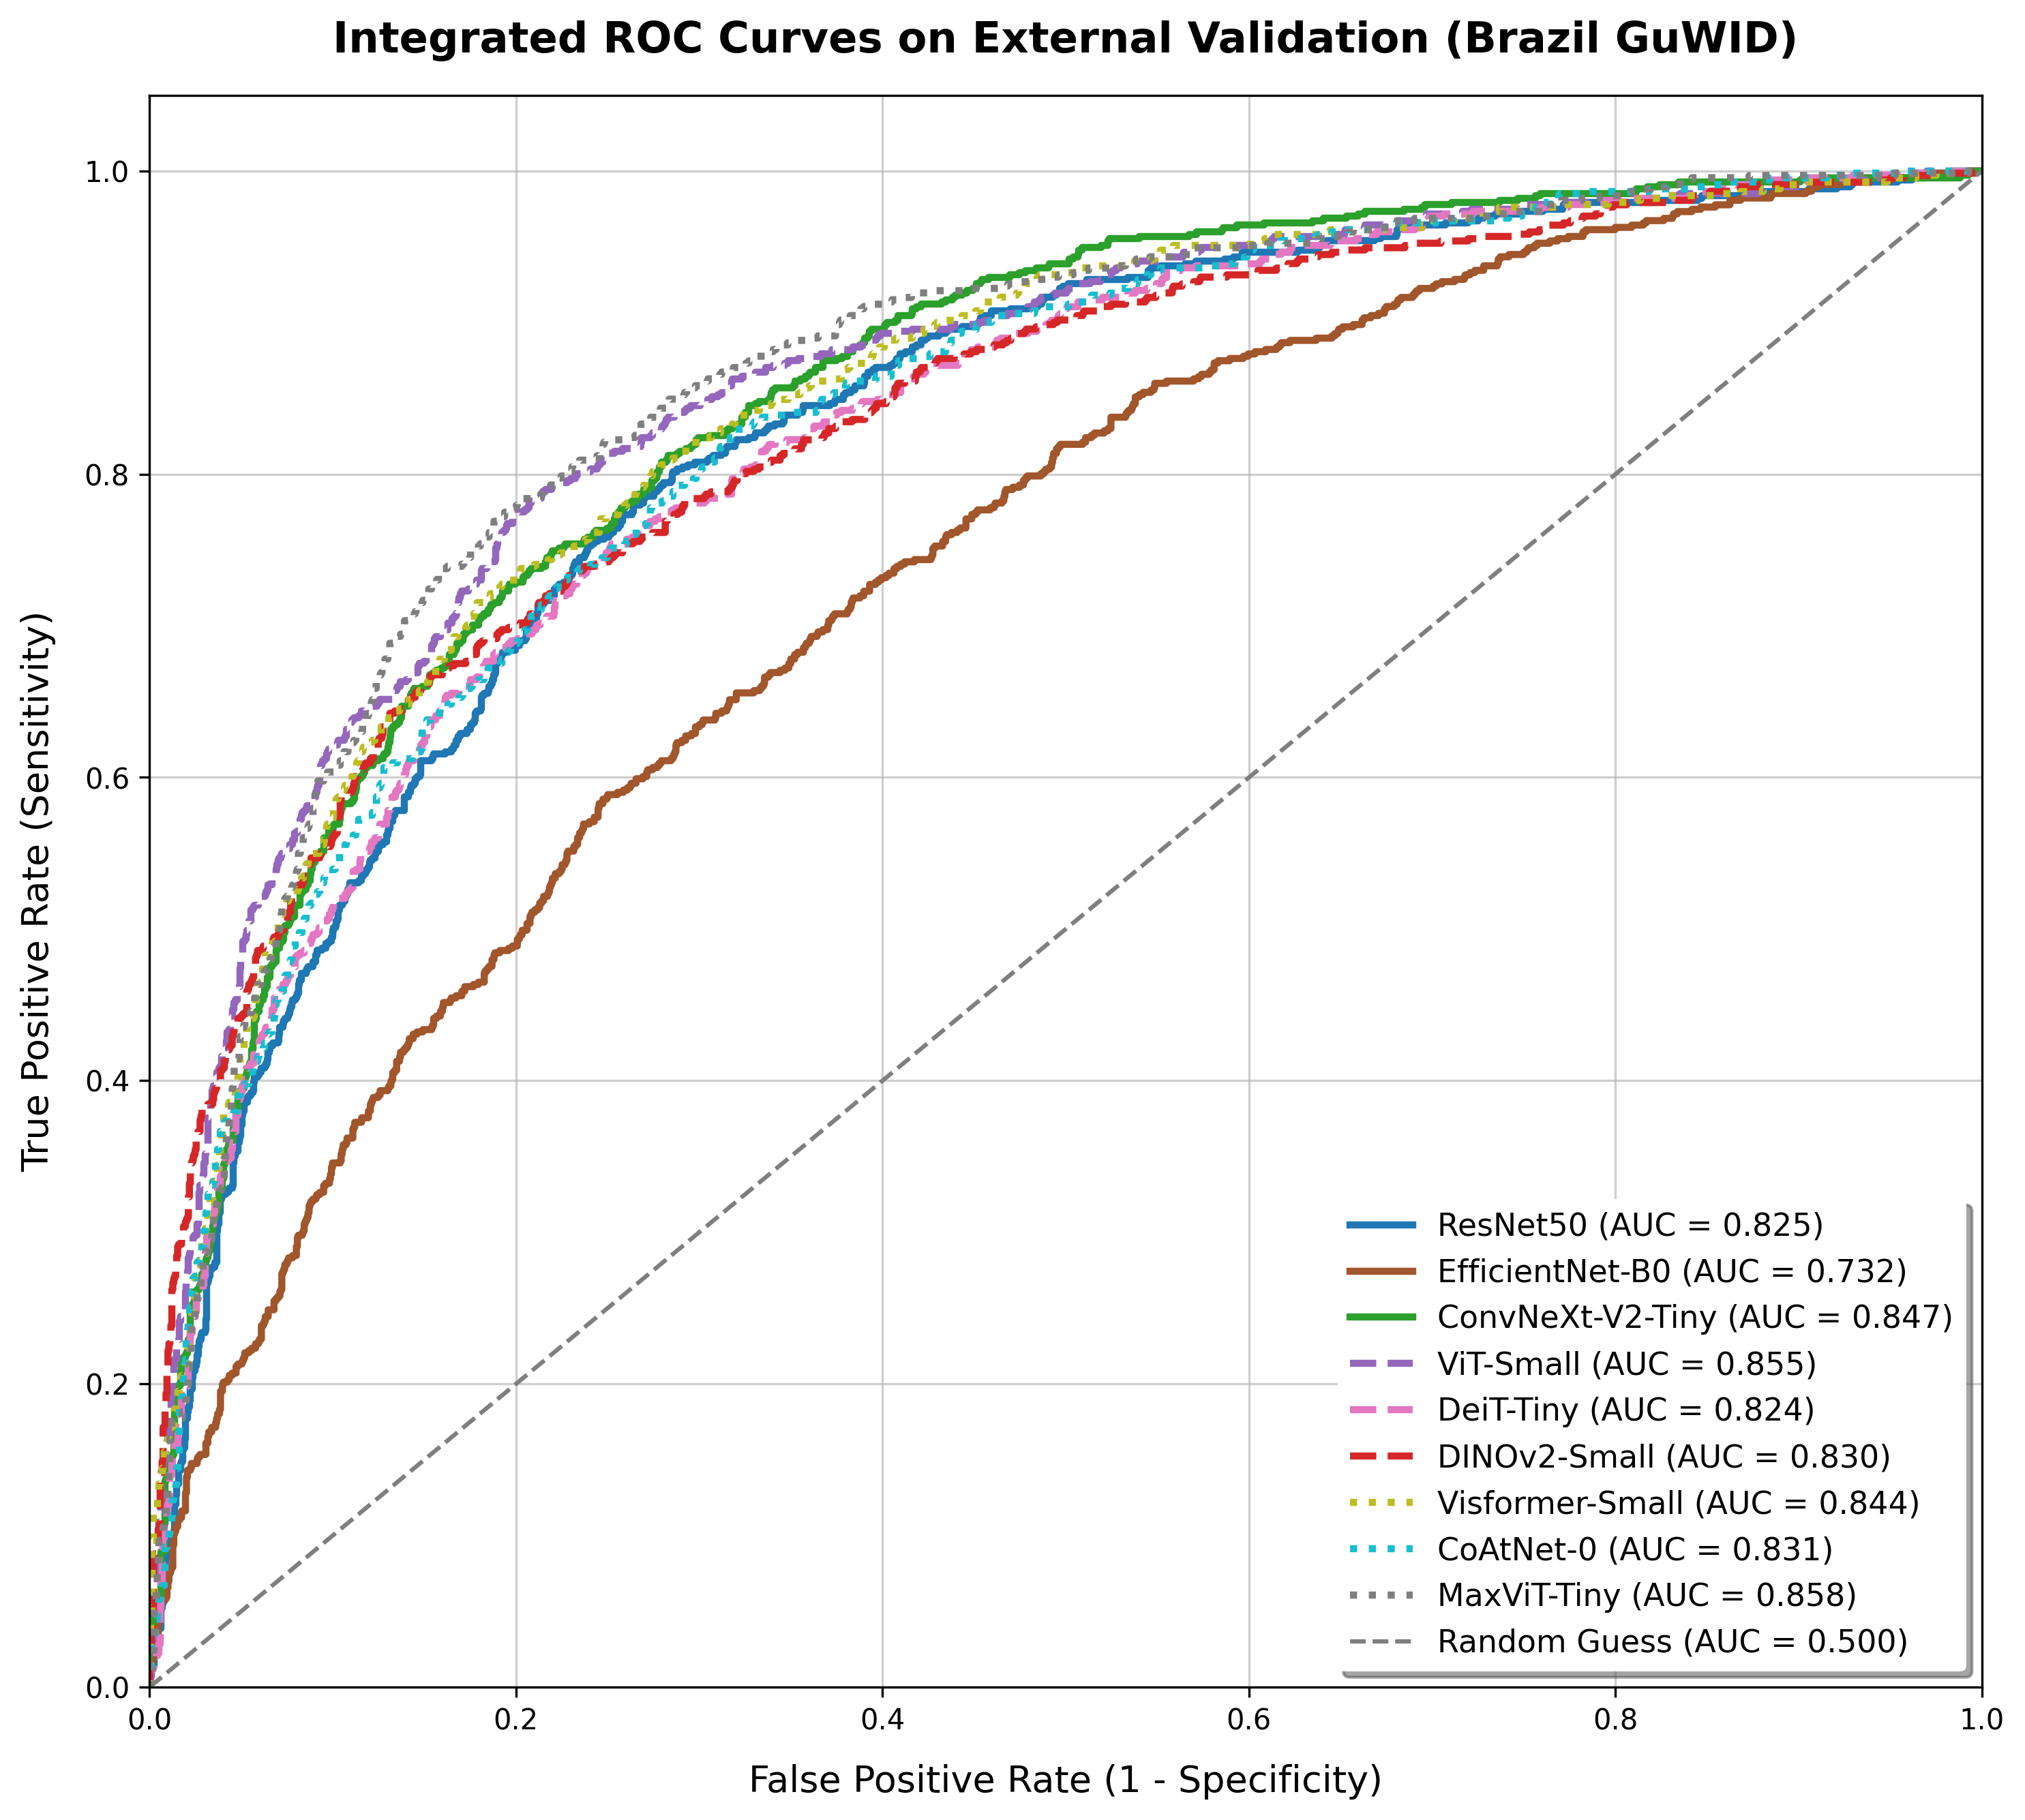

✅ [정밀 사출 완료] 수능 통합 ROC 커브 저장 완료 ➔ /content/drive/MyDrive/CCMEO_Benchmark_Results/GuWID_9_models_external_roc_curves_real.png


In [38]:
# Step 4: External Validation ROC Curves Plotting (0.1s Fast Memory-Based)
import os
import matplotlib.pyplot as plt

print("📉 [Fast Process] 메모리에 완벽 보존된 원본 배열로 진짜 ROC 곡선을 출력합니다...")

model_colors = {
    "ResNet50": "#1f77b4", "EfficientNet-B0": "#a1562c", "ConvNeXt-V2-Tiny": "#2ca02c",
    "ViT-Small": "#9467bd", "DeiT-Tiny": "#e377c2", "DINOv2-Small": "#d62728",
    "Visformer-Small": "#bcbd22", "CoAtNet-0": "#17becf", "MaxViT-Tiny": "#7f7f7f"
}
model_line_styles = {
    "ResNet50": "-", "EfficientNet-B0": "-", "ConvNeXt-V2-Tiny": "-",
    "ViT-Small": "--", "DeiT-Tiny": "--", "DINOv2-Small": "--",
    "Visformer-Small": ":", "CoAtNet-0": ":", "MaxViT-Tiny": ":"
}

plt.figure(figsize=(10, 9), dpi=300)

# 백업된 진짜 fpr, tpr 곡선 배열을 주입하여 정밀 드로잉
for name, data in global_guwid_roc_arrays.items():
    plt.plot(data["fpr"], data["tpr"],
             label=f"{name} (AUC = {data['auc']:.3f})",
             color=model_colors[name],
             linestyle=model_line_styles[name],
             lw=2.5)

plt.plot([0, 1], [0, 1], color='#7f7f7f', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.title('Integrated ROC Curves on External Validation (Brazil GuWID)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13, labelpad=10)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='-', alpha=0.6)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor='white', edgecolor='none', shadow=True)

plt.tight_layout()
ext_roc_path = os.path.join(save_dir, 'GuWID_9_models_external_roc_curves_real.png')
plt.savefig(ext_roc_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

print(f"✅ [정밀 사출 완료] 수능 통합 ROC 커브 저장 완료 ➔ {ext_roc_path}")

📊 [Fast Process] 메모리에 완벽 보존된 원본 배열로 3x3 Confusion Matrix를 출력합니다...


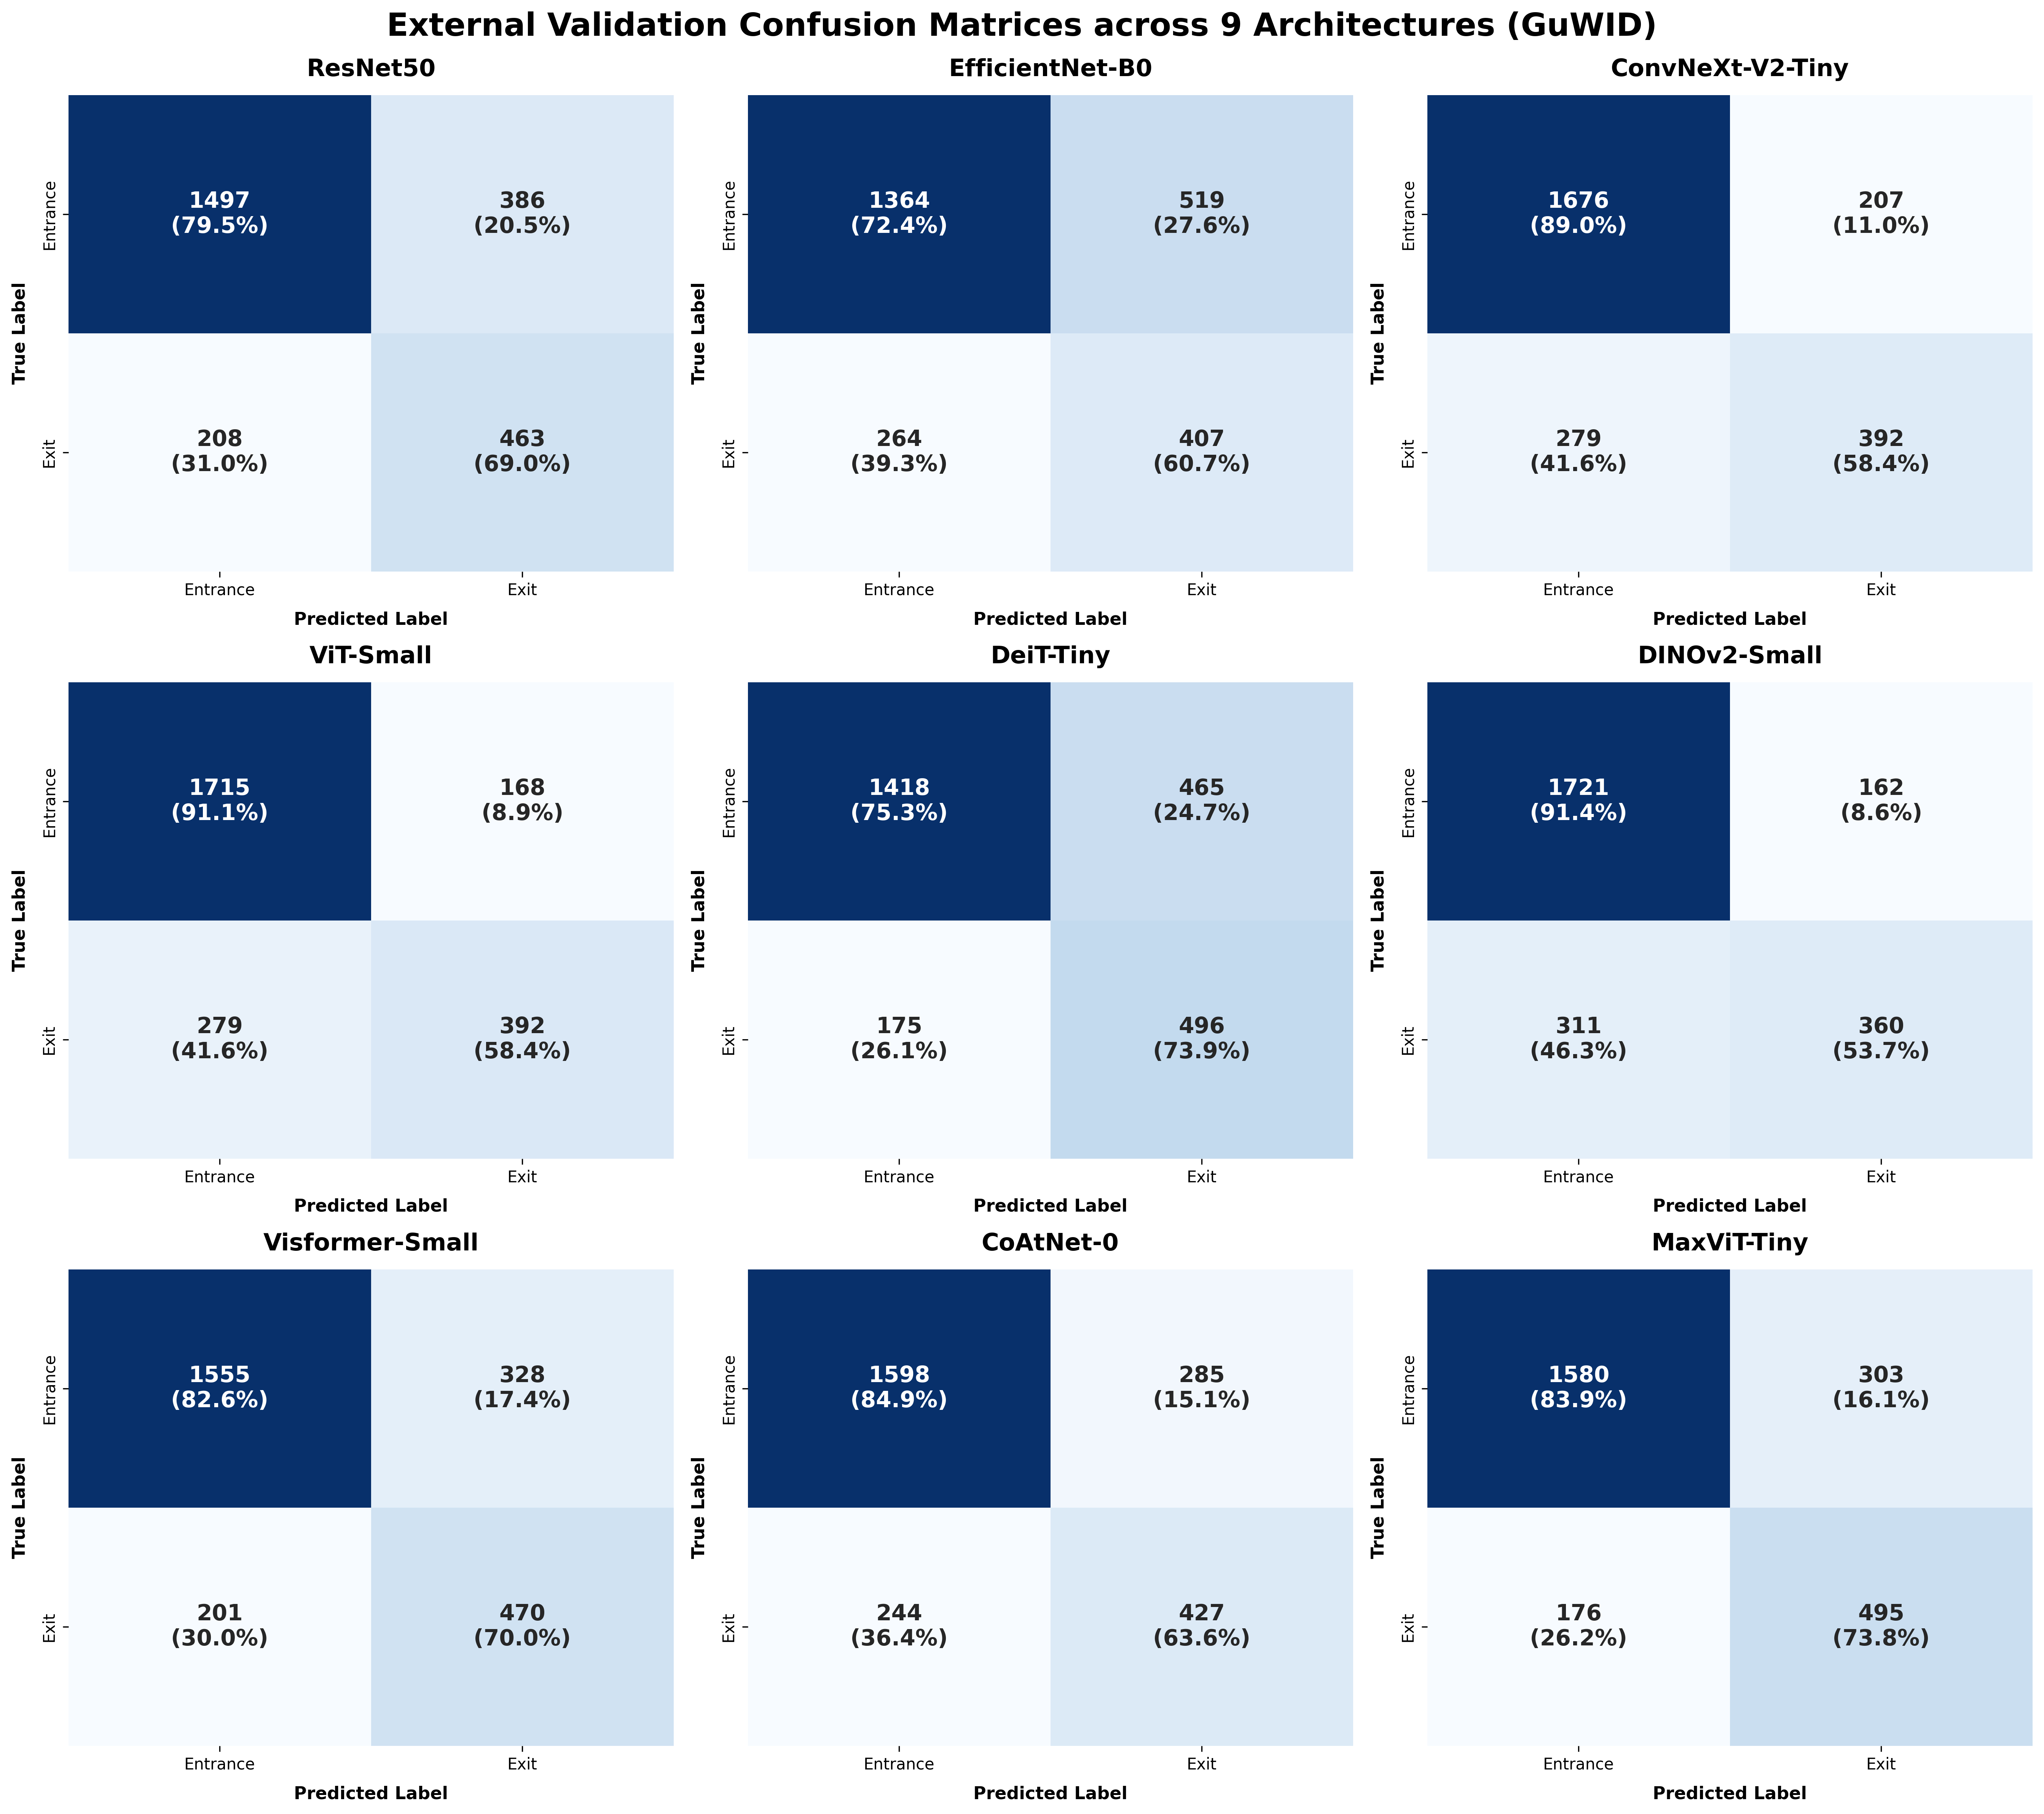

✅ [정밀 사출 완료] 수능 3x3 혼동행렬 격자 저장 완료 ➔ /content/drive/MyDrive/CCMEO_Benchmark_Results/GuWID_9_models_external_confusion_matrix_3x3_real.png


In [39]:
# Step 5: Multi-Model Confusion Matrix Grid for External Validation (0.1s Fast Memory-Based)
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("📊 [Fast Process] 메모리에 완벽 보존된 원본 배열로 3x3 Confusion Matrix를 출력합니다...")

class_names = ['Entrance', 'Exit']
fig, axes = plt.subplots(3, 3, figsize=(18, 16), dpi=300)
axes = axes.ravel()

for idx, (name, data) in enumerate(global_guwid_outputs.items()):
    cm = confusion_matrix(data["labels"], data["preds"])
    cm_ratio = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    labels_text = np.array([[f"{v}\n({r:.1%})" for v, r in zip(row_v, row_r)]
                            for row_v, row_r in zip(cm, cm_ratio)])

    sns.heatmap(cm, annot=labels_text, fmt="", cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14, "weight": "bold"})

    axes[idx].set_title(f"{name}", fontsize=15, fontweight='bold', pad=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=11, fontweight='bold', labelpad=8)
    axes[idx].set_ylabel('True Label', fontsize=11, fontweight='bold', labelpad=8)

for i in range(len(global_guwid_outputs), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('External Validation Confusion Matrices across 9 Architectures (GuWID)', fontsize=20, fontweight='bold', y=0.99)
plt.tight_layout()

ext_cm_path = os.path.join(save_dir, 'GuWID_9_models_external_confusion_matrix_3x3_real.png')
plt.savefig(ext_cm_path, bbox_inches='tight', dpi=300)
plt.show()
plt.close()

print(f"✅ [정밀 사출 완료] 수능 3x3 혼동행렬 격자 저장 완료 ➔ {ext_cm_path}")

In [40]:
# Step 6: Export Sorted External Validation Metrics Table to Excel
import os
import pandas as pd

# 1. 전역 변수에서 데이터를 읽어와 판다스 포맷으로 변환
rows = []
for name, metrics in global_guwid_scores.items():
    rows.append({
        "Model Name": name,
        "Accuracy": metrics["acc"],
        "Precision": metrics["precision"],
        "Recall (Sensitivity)": metrics["recall"],
        "F1-Score": metrics["f1"],
        "ROC-AUC": metrics["auc"]
    })

df_guwid = pd.DataFrame(rows)

# 2. ROC-AUC 점수를 기준으로 내림차순 정렬 (SOTA 아키텍처가 맨 위로 오도록)
df_guwid_sorted = df_guwid.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

# 3. 구글 드라이브 폴더에 마스터 엑셀 표로 저장
save_dir = '/content/drive/MyDrive/CCMEO_Benchmark_Results'
os.makedirs(save_dir, exist_ok=True)
excel_output_path = os.path.join(save_dir, 'GuWID_Brazil_9_models_final_report_sorted.xlsx')

df_guwid_sorted.to_excel(excel_output_path, index=False)

print("\n" + "="*70)
# 정렬된 데이터프레임 콘솔 출력 확인
print(df_guwid_sorted.to_string(index=False))
print("="*70)
print(f"🎉 [성공] 9대 모델 수능 성적 정렬 표가 드라이브에 저장되었습니다!")
print(f"📊 저장 경로 ➔ {excel_output_path}")
print("="*70)


      Model Name  Accuracy  Precision  Recall (Sensitivity)  F1-Score  ROC-AUC
     MaxViT-Tiny  0.812451   0.620301              0.737705  0.673928 0.857659
       ViT-Small  0.824980   0.700000              0.584203  0.636881 0.855004
ConvNeXt-V2-Tiny  0.809710   0.654424              0.584203  0.617323 0.846709
 Visformer-Small  0.792874   0.588972              0.700447  0.639891 0.843766
       CoAtNet-0  0.792874   0.599719              0.636364  0.617498 0.830999
    DINOv2-Small  0.814800   0.689655              0.536513  0.603521 0.830391
        ResNet50  0.767424   0.545347              0.690015  0.609211 0.824848
       DeiT-Tiny  0.749413   0.516129              0.739195  0.607843 0.823834
 EfficientNet-B0  0.693422   0.439525              0.606557  0.509706 0.732151
🎉 [성공] 9대 모델 수능 성적 정렬 표가 드라이브에 저장되었습니다!
📊 저장 경로 ➔ /content/drive/MyDrive/CCMEO_Benchmark_Results/GuWID_Brazil_9_models_final_report_sorted.xlsx
